# Image and Video Feature Extraction


It uses:
- **PCA** to make a compact image representation
- **Canny** to describe image edges
- **ResNet18** to create learned image features
- **Frame differences** to describe video motion



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import models, transforms

image_path = "final.png"
video_path = "video.mp4"


### Update: Added PCA & Canny pipeline notes

### Update: Integrated ResNet18 and motion density

## 1. Load the image


Image size: 2291 x 1648
RGB shape: (1648, 2291, 3)
Gray shape: (1648, 2291)


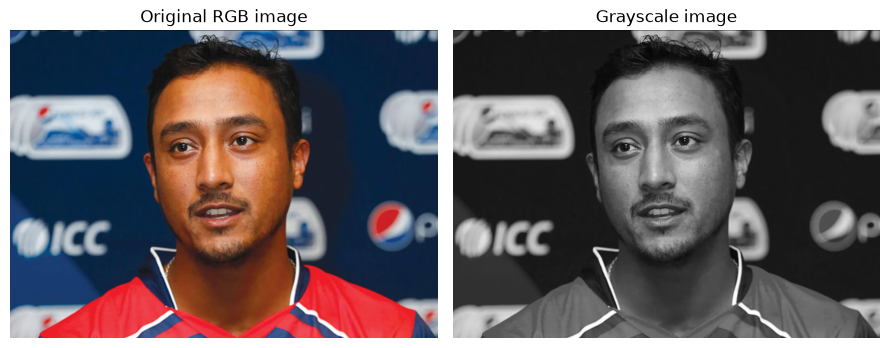

In [2]:
image = Image.open(image_path).convert("RGB")
image_rgb = np.array(image)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

print("Image size:", image_rgb.shape[1], "x", image_rgb.shape[0])
print("RGB shape:", image_rgb.shape)
print("Gray shape:", image_gray.shape)

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original RGB image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.tight_layout()
plt.show()


## 2. PCA features

PCA keeps the directions with the greatest variation. The reconstruction images show how the result changes when we keep different numbers of components.


PCA original shape: (256, 256)
PCA reduced shape: (256, 19)
PCA components for 95% variance: 19
PCA explained variance: 0.9523
PCA reconstruction MSE: 137.12


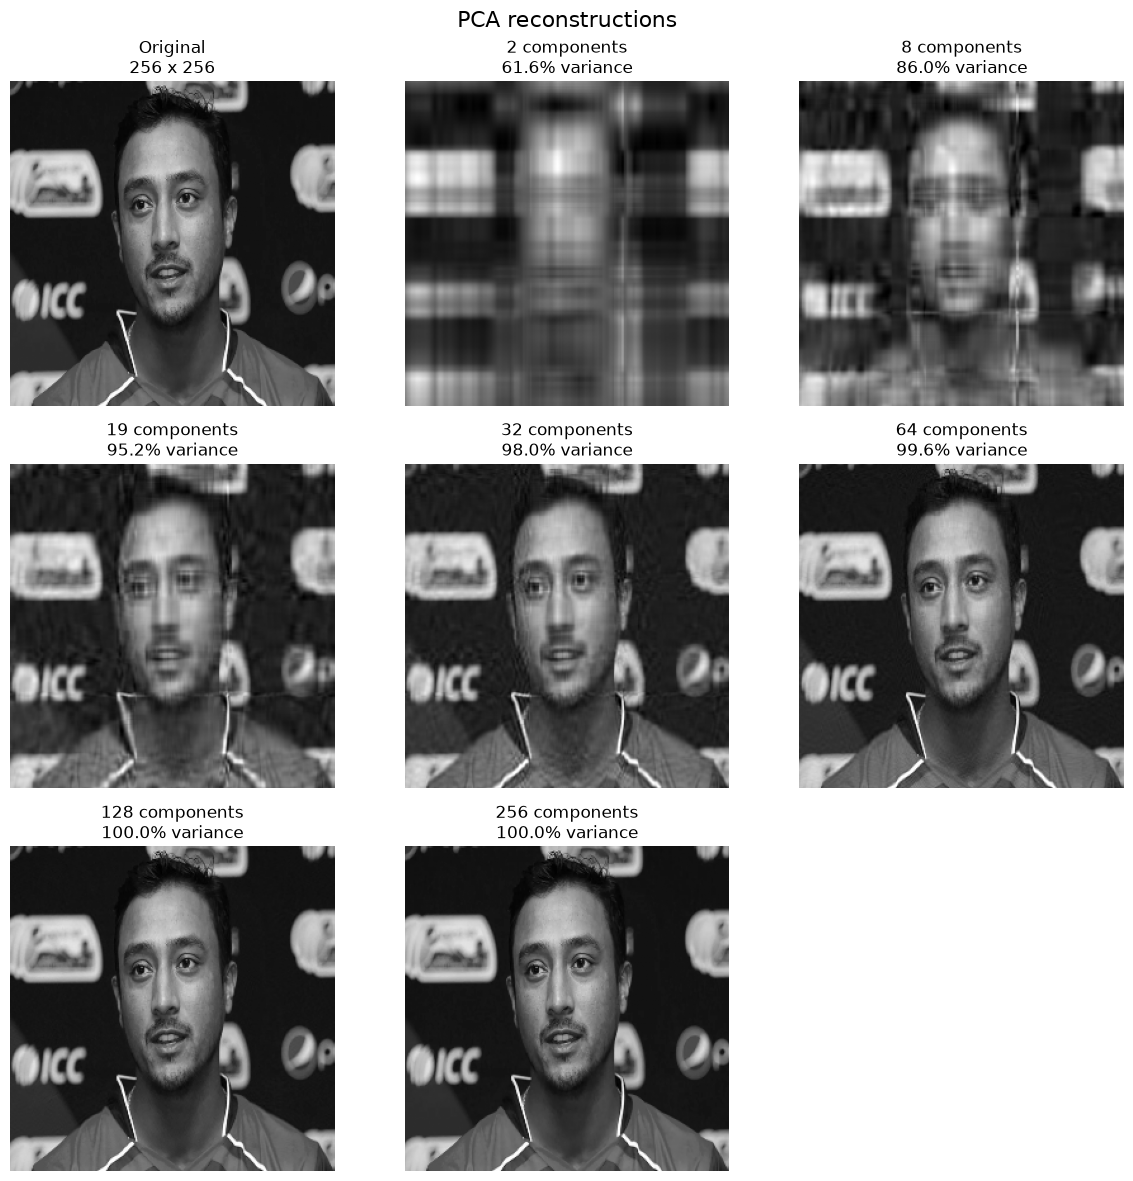

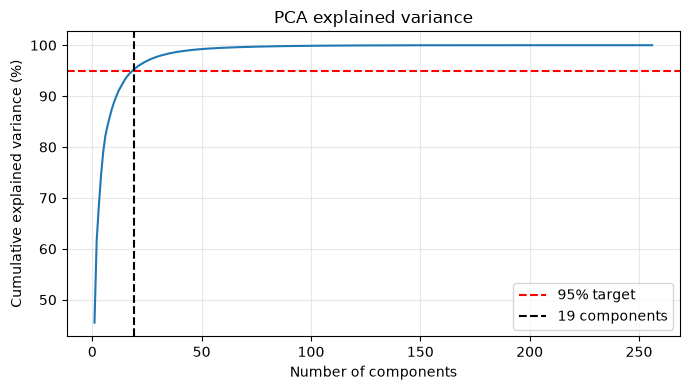

In [ ]:
pca_input = cv2.resize(image_gray, (256, 256)).astype(float)

# Center each image column around its average value.
pca_mean = pca_input.mean(axis=0)
pca_centered = pca_input - pca_mean

# SVD gives the PCA directions and their importance.
_, singular_values, vh = np.linalg.svd(
    pca_centered,
    full_matrices=False
)

pca_variance = singular_values ** 2
pca_variance_ratio = pca_variance / pca_variance.sum()
pca_cumulative = np.cumsum(pca_variance_ratio) 
pca_components = np.argmax(pca_cumulative >= 0.95) + 1

# Keep the number of components that explains at least 95% of the variance.
pca_basis = vh[:pca_components]
pca_reduced = pca_centered @ pca_basis.T
pca_reconstructed = pca_reduced @ pca_basis + pca_mean
pca_mse = np.mean((pca_input - pca_reconstructed) ** 2)

print("PCA original shape:", pca_input.shape)
print("PCA reduced shape:", pca_reduced.shape)
print("PCA components for 95% variance:", pca_components)
print("PCA explained variance:", round(pca_cumulative[pca_components - 1], 4))
print("PCA reconstruction MSE:", round(pca_mse, 2))

# Reconstruct.
pca_counts = [2, 8, pca_components, 32, 64, 128, 256]
pca_counts = sorted(set(count for count in pca_counts if count <= 256))
pca_images = [pca_input]
pca_titles = ["Original\n256 x 256"]

for count in pca_counts:
    basis = vh[:count]
    reduced_image = pca_centered @ basis.T
    reconstructed_image = reduced_image @ basis + pca_mean
    pca_images.append(np.clip(reconstructed_image, 0, 255))
    explained = pca_cumulative[count - 1] * 100
    pca_titles.append(f"{count} components\n{explained:.1f}% variance")

rows = int(np.ceil(len(pca_images) / 3))
plt.figure(figsize=(12, 4 * rows))
for index, (image_to_show, image_title) in enumerate(zip(pca_images, pca_titles)):
    plt.subplot(rows, 3, index + 1)
    plt.imshow(image_to_show, cmap="gray")
    plt.title(image_title)
    plt.axis("off")
plt.suptitle("PCA reconstructions", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, 257), pca_cumulative * 100)
plt.axhline(95, color="red", linestyle="--", label="95% target")
plt.axvline(
    pca_components,
    color="black",
    linestyle="--",
    label=f"{pca_components} components"
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("PCA explained variance")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Canny edge features

Canny finds image boundaries. 
The 4 x 4 heatmap turns the edge image into 16 numbers showing where edges are concentrated.


Edge image shape: (256, 256)
Edge pixels: 4311 of 65536
Global edge density: 0.0658
Canny feature length: 16
Canny block features: [0.031 0.035 0.072 0.027 0.068 0.116 0.105 0.028 0.084 0.102 0.096 0.068
 0.036 0.062 0.076 0.046]


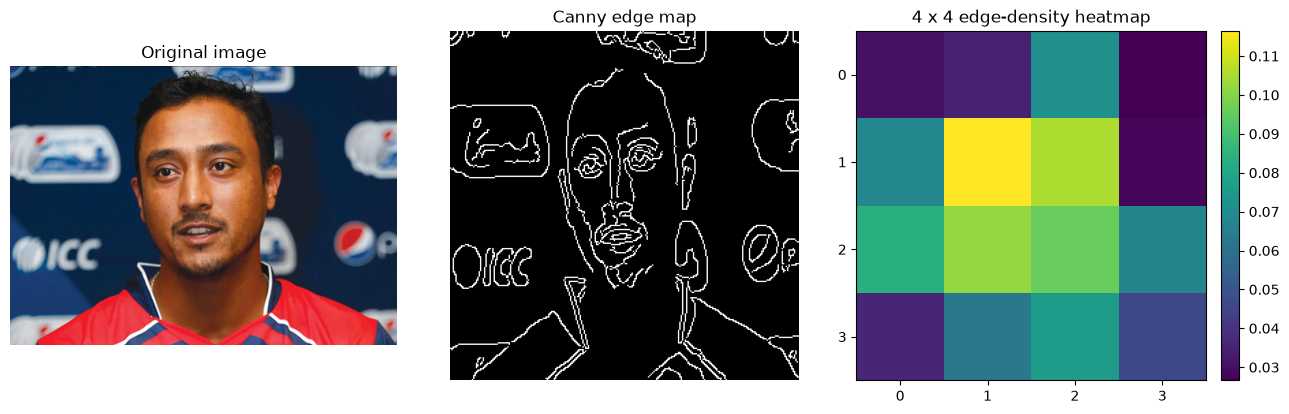

In [4]:
canny_input = cv2.resize(image_gray, (256, 256))
blurred = cv2.GaussianBlur(canny_input, (5, 5), 0)
edge_image = cv2.Canny(blurred, 50, 150)
global_edge_density = np.mean(edge_image > 0)

block_features = []
block_densities = np.zeros((4, 4))
block_size = edge_image.shape[0] // 4

for row in range(4):
    for column in range(4):
        top = row * block_size
        left = column * block_size
        block = edge_image[
            top:top + block_size,
            left:left + block_size
        ]
        value = np.mean(block > 0)
        block_densities[row, column] = value
        block_features.append(value)

print("Edge image shape:", edge_image.shape)
print("Edge pixels:", int(np.count_nonzero(edge_image)), "of", edge_image.size)
print("Global edge density:", round(global_edge_density, 4))
print("Canny feature length:", len(block_features))
print("Canny block features:", np.round(block_features, 3))

plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_image, cmap="gray")
plt.title("Canny edge map")
plt.axis("off")

plt.subplot(1, 3, 3)
heatmap = plt.imshow(block_densities, cmap="viridis")
plt.title("4 x 4 edge-density heatmap")
plt.xticks(range(4))
plt.yticks(range(4))
plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 4. ResNet18 features

ResNet18 is a pretrained neural network used here only as a feature extractor. 
Its intermediate maps show learned patterns, and its final output is a 512-value image feature.


ResNet input tensor: (1, 3, 224, 224)
ResNet feature length: 512
ResNet first 10 values: [0.291  0.6585 0.4293 2.1357 0.4118 0.012  0.4654 0.2333 0.1356 0.7142]
ResNet L2 norm: 24.8557
ResNet min / mean / max: 0.0 0.7787 5.8715


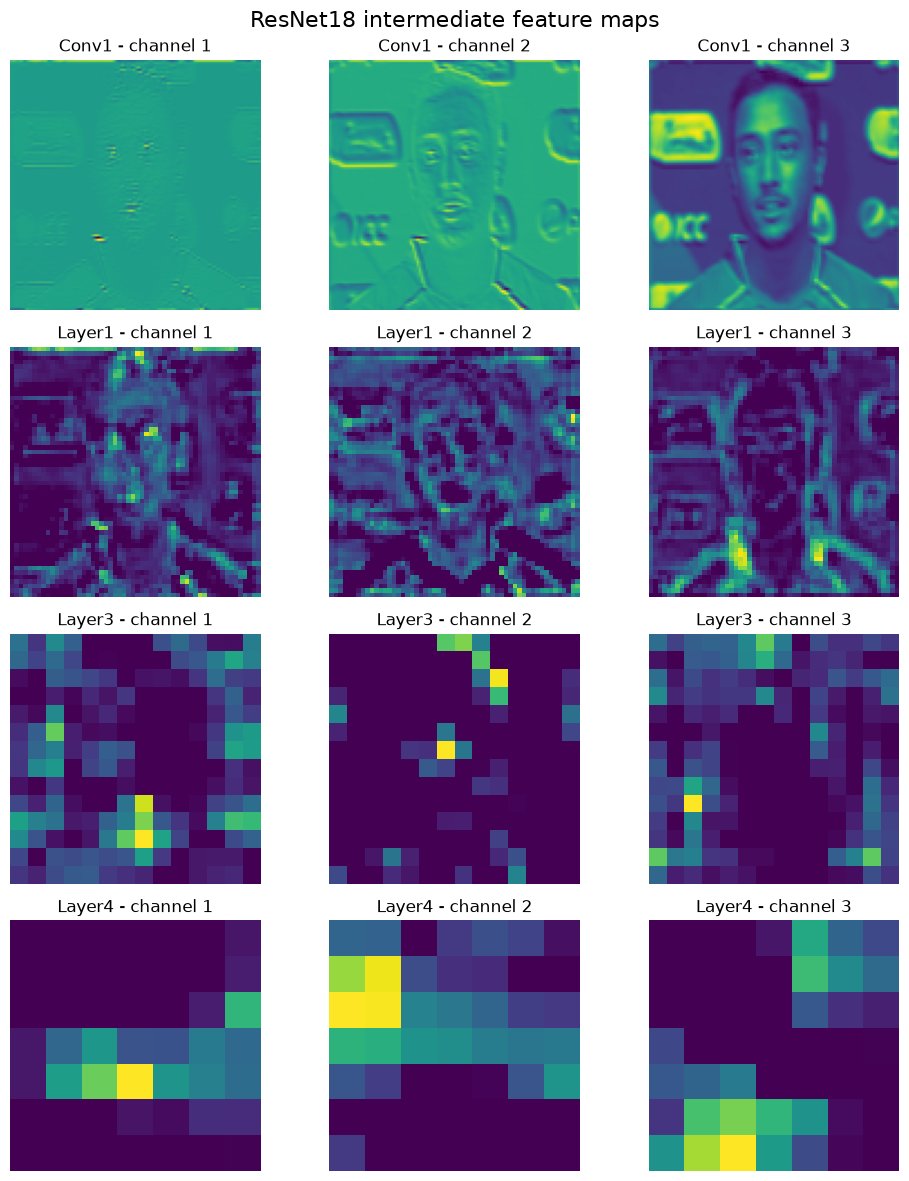

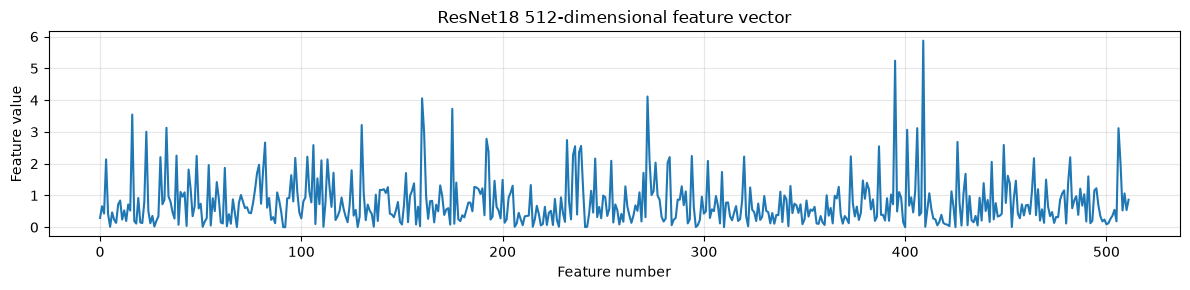

In [ ]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Remove the classifier so the model returns its 512-value image feature.
model.fc = torch.nn.Identity()
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(image).unsqueeze(0)
feature_maps = {}


def save_features(name):
    def hook(layer, inputs, output):
        feature_maps[name] = output.detach()
    return hook

layers = {
    "Conv1": model.conv1,
    "Layer1": model.layer1,
    "Layer3": model.layer3,
    "Layer4": model.layer4
}

handles = []
for name, layer in layers.items():
    handles.append(layer.register_forward_hook(save_features(name)))

with torch.no_grad():
    deep_features = model(input_tensor).squeeze().cpu().numpy()

for handle in handles:
    handle.remove()

print("ResNet input tensor:", tuple(input_tensor.shape))
print("ResNet feature length:", len(deep_features))
print("ResNet first 10 values:", np.round(deep_features[:10], 4))
print("ResNet L2 norm:", round(np.linalg.norm(deep_features), 4))
print("ResNet min / mean / max:", round(deep_features.min(), 4),
      round(deep_features.mean(), 4), round(deep_features.max(), 4))

plt.figure(figsize=(10, 12))
for row, (name, fmap) in enumerate(feature_maps.items()):
    fmap = fmap[0]
    for column in range(3):
        plt.subplot(4, 3, row * 3 + column + 1)
        plt.imshow(fmap[column].cpu().numpy(), cmap="viridis")
        plt.title(f"{name} - channel {column + 1}")
        plt.axis("off")
plt.suptitle("ResNet18 intermediate feature maps", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(deep_features)
plt.title("ResNet18 512-dimensional feature vector")
plt.xlabel("Feature number")
plt.ylabel("Feature value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Video features

For every video frame,measure edge density and motion density. 



In [6]:
video = cv2.VideoCapture(video_path)
fps = video.get(cv2.CAP_PROP_FPS)
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
video_width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps

sample_numbers = {
    int(total_frames * 0.2),
    int(total_frames * 0.5),
    int(total_frames * 0.8)
}
video_times = []
video_edges = []
video_motion = []
representative = {}
previous_gray = None
frame_number = 0

while True:
    success, frame = video.read()
    if not success:
        break

    # Use one simple size for every video frame.
    frame = cv2.resize(frame, (640, 360))
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    blurred_frame = cv2.GaussianBlur(gray_frame, (5, 5), 0)
    frame_edges = cv2.Canny(blurred_frame, 50, 150)
    edge_value = np.mean(frame_edges > 0)

    if previous_gray is None:
        motion_mask = np.zeros_like(gray_frame)
    else:
        difference = cv2.absdiff(gray_frame, previous_gray)
        motion_mask = (difference > 25).astype(np.uint8) * 255

    motion_value = np.mean(motion_mask > 0)
    current_time = frame_number / fps

    video_times.append(current_time)
    video_edges.append(edge_value)
    video_motion.append(motion_value)

    if frame_number in sample_numbers:
        representative[frame_number] = {
            "rgb": cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            "edges": frame_edges,
            "motion": motion_mask,
            "time": current_time
        }

    previous_gray = gray_frame
    frame_number += 1

video.release()

video_times = np.array(video_times)
video_edges = np.array(video_edges)
video_motion = np.array(video_motion)

print("Video resolution:", video_width, "x", video_height)
print("Video FPS:", round(fps, 2))
print("Video frames:", total_frames)
print("Video duration:", round(duration, 2), "seconds")
print("Frames processed:", frame_number)
print("Edge density min / mean / max:", round(video_edges.min(), 4),
      round(video_edges.mean(), 4), round(video_edges.max(), 4))
print("Motion density min / mean / max:", round(video_motion.min(), 4),
      round(video_motion.mean(), 4), round(video_motion.max(), 4))


Video resolution: 1920 x 1080
Video FPS: 23.98
Video frames: 361
Video duration: 15.06 seconds
Frames processed: 361
Edge density min / mean / max: 0.1724 0.1814 0.1907
Motion density min / mean / max: 0.0 0.0065 0.0571


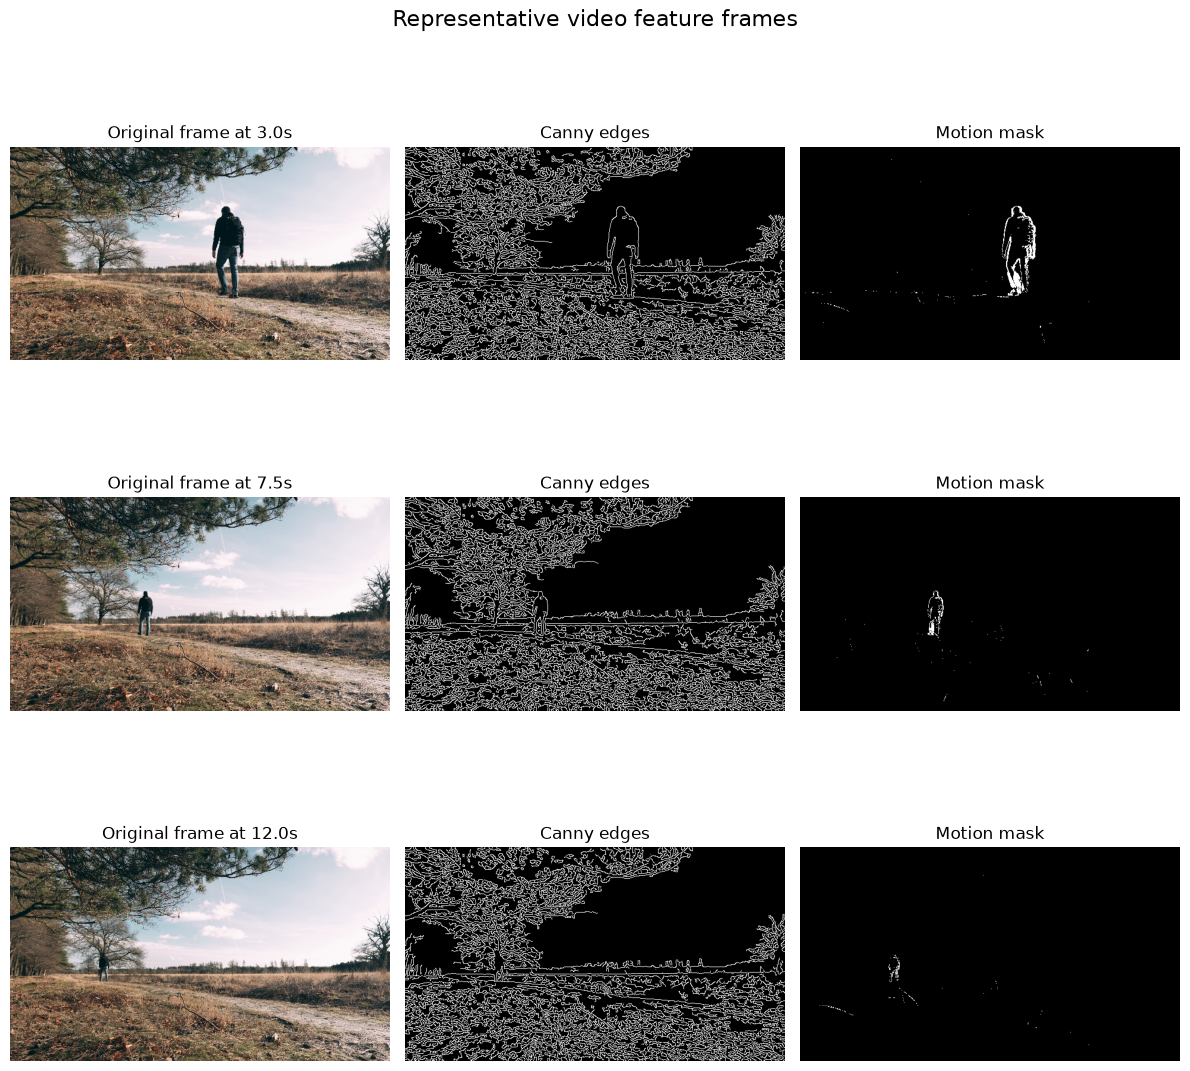

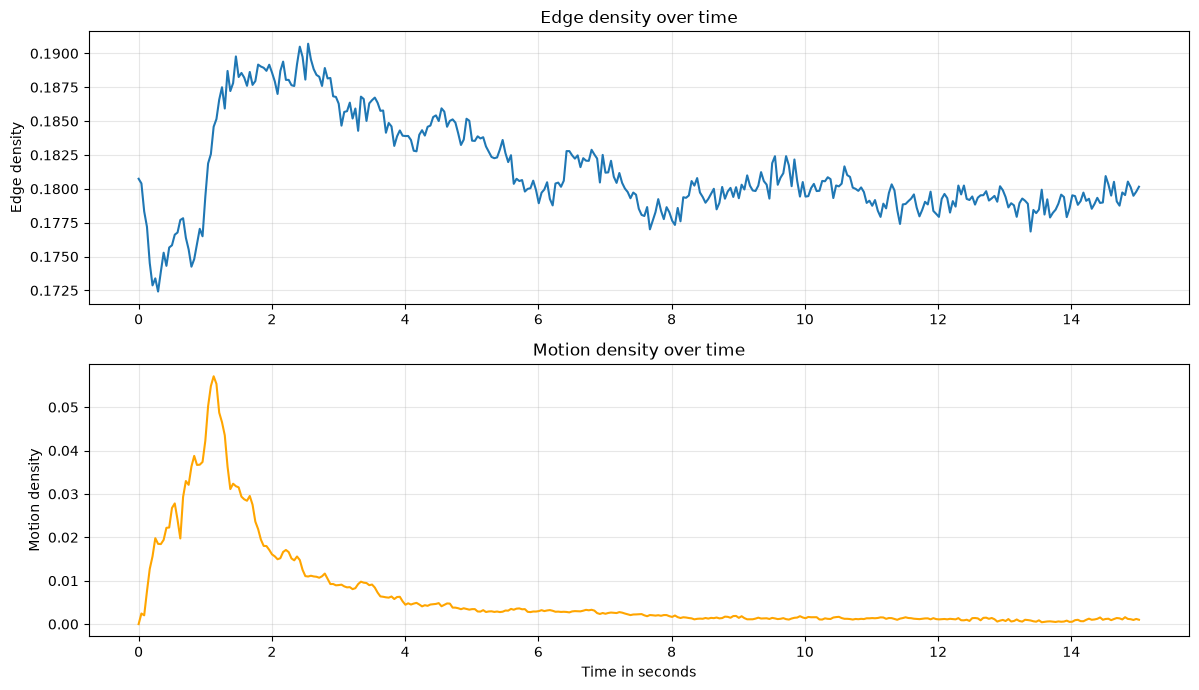

In [7]:
sample_keys = sorted(representative)
plt.figure(figsize=(12, 4 * len(sample_keys)))

for row, key in enumerate(sample_keys):
    frame_data = representative[key]

    plt.subplot(len(sample_keys), 3, row * 3 + 1)
    plt.imshow(frame_data["rgb"])
    plt.title(f"Original frame at {frame_data['time']:.1f}s")
    plt.axis("off")

    plt.subplot(len(sample_keys), 3, row * 3 + 2)
    plt.imshow(frame_data["edges"], cmap="gray")
    plt.title("Canny edges")
    plt.axis("off")

    plt.subplot(len(sample_keys), 3, row * 3 + 3)
    plt.imshow(frame_data["motion"], cmap="gray")
    plt.title("Motion mask")
    plt.axis("off")

plt.suptitle("Representative video feature frames", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.subplot(2, 1, 1)
plt.plot(video_times, video_edges)
plt.title("Edge density over time")
plt.ylabel("Edge density")
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(video_times, video_motion, color="orange")
plt.title("Motion density over time")
plt.xlabel("Time in seconds")
plt.ylabel("Motion density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
print("Feature summary")
print("PCA:", pca_reduced.shape, "reduced coefficients")
print("Canny:", len(block_features), "block edge-density values")
print("ResNet18:", len(deep_features), "deep feature values")
print("Video:", len(video_times), "time steps")

Feature summary
PCA: (256, 19) reduced coefficients
Canny: 16 block edge-density values
ResNet18: 512 deep feature values
Video: 361 time steps


In [9]:
video = cv2.VideoCapture(video_path)
fps = video.get(cv2.CAP_PROP_FPS)

out = cv2.VideoWriter(
    "motion_map.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (640, 360),
    isColor=False
)

previous_gray = None

while True:
    success, frame = video.read()
    if not success:
        break

    frame = cv2.resize(frame, (640, 360))
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if previous_gray is None:
        motion_mask = np.zeros_like(gray_frame)
    else:
        difference = cv2.absdiff(gray_frame, previous_gray)
        motion_mask = (difference > 25).astype(np.uint8) * 255

    out.write(motion_mask)
    previous_gray = gray_frame

video.release()
out.release()
print("Saved motion_map.mp4")

Saved motion_map.mp4
